# Final Project - Reinforcements Learning

Maor Hornstein, 300278520
<br>

<img src="https://play-lh.googleusercontent.com/e_oKlKPISbgdzut1H9opevS7-LTB8-8lsmpCdMkhlnqFenZhpjxbLmx7l158-xQQCIY">

# Introduction

TODO

# Installs

Please enable this cell when running on colab environment:

In [41]:
'''
%%capture
!sudo apt-get update
!sudo apt-get install -y xvfb ffmpeg freeglut3-dev
!pip install 'imageio==2.4.0'
!pip install gym
!pip install pygame
!apt-get install python-opengl -y
!apt install xvfb -y
!pip install pyvirtualdisplay
!pip install piglet
!pip install gym
!apt-get install python-opengl -y
!apt install xvfb -y
!pip install gym_sokoban
!git clone https://github.com/avivg7/sokoban-so.git
!unzip /content/sokoban-so/Compress.zip
'''

"\n%%capture\n!sudo apt-get update\n!sudo apt-get install -y xvfb ffmpeg freeglut3-dev\n!pip install 'imageio==2.4.0'\n!pip install gym\n!pip install pygame\n!apt-get install python-opengl -y\n!apt install xvfb -y\n!pip install pyvirtualdisplay\n!pip install piglet\n!pip install gym\n!apt-get install python-opengl -y\n!apt install xvfb -y\n!pip install gym_sokoban\n!git clone https://github.com/avivg7/sokoban-so.git\n!unzip /content/sokoban-so/Compress.zip\n"

# Imports

In [1]:
import os
import sys
if os.name == 'nt': # this means we run locally on windows
    sys.path.append('../')

In [2]:
import numpy as np
import gym
from gym import logger as gymlogger
from gym.utils import seeding
from gym import error, spaces, utils
gymlogger.set_level(40) # error only
from soko_pap import *
import glob
import io
import base64
import os
import random
import matplotlib.pyplot as plt
%matplotlib inline
import math
import glob
from pyvirtualdisplay import Display
from IPython.display import HTML
from IPython import display as ipythondisplay
import pygame
import pyvirtualdisplay
import imageio
import IPython
import time

# Display utils
Note: I changed this cell as I worked on windows os, and PyVirtualDisplay doesn't work on windows.
link for reference: https://stackoverflow.com/questions/43270513/is-there-a-windows-equivalent-to-pyvirtualdisplay

In [4]:
import cv2
from base64 import b64encode

if os.name == 'nt': # this means we run locally on windows
  video_count = 0
  def create_video(images):
    global video_count
    video_count += 1
    video_name = f'video_{video_count}.mp4'
    frame = images[0]
    height, width, layers = frame.shape

    video = cv2.VideoWriter(video_name, 0, 3, (width,height))

    for image in images:
      video.write(image)

    cv2.destroyAllWindows()
    video.release()
  
    mp4 = open(video_name,'rb').read()   
    data_url = "data:video/mp4;base64," + b64encode(mp4).decode()
    display(
      HTML(
            """
                <video width=400 controls>
                        <source src="%s" type="video/mp4">
                </video>
            """ % data_url
          )   
    )
    print(f'video file name: {video_name}')
      
else: # this is posix, as it runs online. use assigment video solution
  def create_video(images):
    video_filename = 'imageio.mp4'
    with imageio.get_writer(video_filename, fps=10) as video:
        for image in images: video.append_data(image)

    video = open(video_filename,'rb').read()
    b64 = base64.b64encode(video)
    tag = '''
    <video width="640" height="480" controls>
      <source src="data:video/mp4;base64,{0}" type="video/mp4">
    Your browser does not support the video tag.
    </video>'''.format(b64.decode())

    return IPython.display.HTML(tag)
  display = pyvirtualdisplay.Display(visible=0, size=(1400, 900)).start() 


# Additional utilities

Environment Customization:

In [5]:
import copy

class EnvWrapper(gym.Env):
    '''
    This wrapper enables environment customization:
    * simulating stochastic environment.

    The implementation is based on the notebook:
    https://colab.research.google.com/drive/1ohrs6k0m17tPoQehdInUwwdj0g3H0vra?usp=sharing#scrollTo=XXqIDAd1SeMX

    but makes use of the Sokoban env instead.
    '''

    def __init__(self, num_boxes=1, compliance=0.9):
        '''
        :param num_boxes: number of boxes in the sokoban env
        :param compliance: when the agent takes a certain action, this is the probability that the environment will
        '''
        self.num_boxes = num_boxes

        self.source_env = PushAndPullSokobanEnv(dim_room=(7, 7), num_boxes=num_boxes, max_steps=500)
        self.reset()

        # creating stochactic transition mapping
        n = self.env.action_space.n
        self.action_list = list(range(n))

        self.action_dist = {}
        for action in self.action_list:
            dist = [(1 - compliance) / (n - 1) for i in range(n)]
            dist[action] = compliance
            self.action_dist[action] = dist

        # self.render()

    def step(self, action):
        dist = self.action_dist[action]
        chosen_action = random.choices(self.action_list, dist)[0]

        state, reward, done, info = self.env.step(chosen_action)
        reward = self.calc_reward()
        state = self.get_current_state()

        return state, reward, done, info

    def reset(self): # open gym reset changes the board. override, as we do not want to change the board upon reset
        self.env = copy.deepcopy(self.source_env)
        return self.get_current_state()

    def change_board(self):
        self.source_env.reset()
        self.reset()

    def get_current_state(self): # Returns a simplified version of the state.
        rgb_display = self.env.render(mode='tiny_rgb_array')
        grayscale_display = np.dot(rgb_display[..., :3], [0.2989, 0.5870, 0.1140]) # refernece: https://stackoverflow.com/questions/12201577/how-can-i-convert-an-rgb-image-into-grayscale-in-python
        return grayscale_display

    def render(self, mode='tiny_rgb_array'):
        return self.env.render(mode) # Note: this is the single change from the function used locally

    def sample_action(self):
        return self.env.action_space.sample()

    def get_states_dim(self):
        current_state = self.get_current_state()
        return current_state.shape

    def action_space(self):
        return self.env.action_space

    def calc_reward(self):
        reward = 0
        room_state = self.env.room_state
        box_positions = np.argwhere(room_state == 4)
        target_positions = np.argwhere(room_state == 2)
        for box_position in box_positions:
            for target_position in target_positions:
                manhattan_distance = np.sum(np.abs(box_position - target_position))
                reward -= manhattan_distance
        return float(reward)


Video streaming:

In [6]:
def stream_policy(env, policy, iter_tresshold=None):
  # Step 1: collect images
  state = env.reset()
  start_time = time.time()
  done = False
  iter = 0
  images = []
  images.append(env.render(mode='rgb_array'))

  while not(iter_tresshold is not None and iter >= iter_tresshold) and not done:
    time_passed = int(time.time() - start_time)
    if done or time_passed > 3:
      break
    iter +=1
    action = policy(state)
    state, reward, done, info = env.step(action)
    images.append(env.render(mode='rgb_array'))
  # Than - create video
  return create_video(images)

The DQN algorithm

In [7]:
from collections import deque

import torch
import torch.nn as nn
import torch.optim as optim

class DQN_Net(nn.Module):
    def __init__(self, input_shape, output_shape, layers_sizes):
        super(DQN_Net, self).__init__()
        input_size = input_shape[0] * input_shape[1]
        layer_sizes = [input_size] + layers_sizes + [output_shape]
        layers = []
        for i in range(len(layer_sizes) - 1):
            layers.append(nn.Linear(layer_sizes[i], layer_sizes[i+1]))
            if i < len(layer_sizes) - 2: # Do not add relu layer after the last linear layer - this is where the softmax is
                layers.append(nn.ReLU())

        self.model = nn.Sequential(*layers)
    
    def forward(self, x):
        size = x.size()
        flattened_size = size[0], -1
        return self.model(x.view(flattened_size))

def train_action_value_network(action_value_net, target_net, batch, gamma, criterion, optimizer):
    states, actions, rewards, next_states, dones = batch

    '''
    In this part, we Convert all the matrices
    Only this part was inspired by the ATARI DQN implamantation paper: https://github.com/BY571/DQN-Atari-Agents/blob/master/Agents/dqn_agent.py
    '''
    states = torch.stack([torch.tensor(arr, dtype=torch.float32) for arr in states], dim=0)
    actions = torch.LongTensor(actions).unsqueeze(1)
    rewards = torch.FloatTensor(rewards).unsqueeze(1)
    next_states = torch.stack([torch.tensor(arr, dtype=torch.float32) for arr in next_states], dim=0)
    dones = torch.FloatTensor(dones).unsqueeze(1)

    q_values = action_value_net(states).gather(1, actions)
    next_q_values = target_net(next_states).max(1)[0].unsqueeze(1)

    '''
    This is the matrix-way to write the following for a single state:
    if done:
            target = r
        else:
            target = r + gamma * np.amax(target_net.predict(np.array([s_tag,]))
    '''
    target_q_values = rewards + (1 - dones) * gamma * next_q_values

    loss = criterion(q_values, target_q_values)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    return loss.item()

def dqn(env, num_episodes, batch_size, gamma, ep_decay, epsilon,
        target_freq_update, memory_buffer_size, learning_rate, steps_cutoff, fixed_board,
        layers_sizes, train_action_value_freq_update):
    net_performance = []

    done_count = 0
    episodes_steps = []
    episodes_rewards = []

    # create a memory buffer
    memory_buffer = deque(maxlen=memory_buffer_size)

    # create both agent and target nets
    states_dim = env.get_states_dim()
    actions_dim = env.action_space().n

    action_value_net = DQN_Net(states_dim, actions_dim, layers_sizes)
    target_net = DQN_Net(states_dim, actions_dim, layers_sizes)
    target_net.load_state_dict(action_value_net.state_dict())

    optimizer = optim.Adam(action_value_net.parameters(), lr=learning_rate)
    criterion = nn.MSELoss()

    # Start running episodes
    for ep in range(1, num_episodes+1):
        # print(f'running ep: {ep}. Steps: ', end ='')
        if not fixed_board:
            env.change_board()
        s = env.reset()
        # env.render()

        done = False
        steps_count = 1
        reward_sum = 0

        while not done and steps_count < steps_cutoff:
            # print(f'{steps_count}', end= ' ')
            # Step 1: Choose an action a based on current policy (e.g. 𝜀 − 𝑔𝑟𝑒𝑒𝑑𝑦))
            if np.random.rand() <= epsilon:
                a = env.sample_action()
            else:
                state = torch.FloatTensor(s).unsqueeze(0)
                with torch.no_grad():
                    q_values = action_value_net(state)
                a = torch.argmax(q_values).item()

            # Step 2: You get a reward r. You are now in state s’
            s_tag, r, done, info = env.step(a)

            # Step 3: save the result of the step in memory
            memory_buffer.append((s, a, r, s_tag, done))

            # Step 4: train the agent network
            if len(memory_buffer) > batch_size and steps_count % train_action_value_freq_update == 0:
                batch = zip(*random.sample(memory_buffer, batch_size))
                loss = train_action_value_network(action_value_net, target_net, batch, gamma, criterion, optimizer)
                net_performance.append({
                    'ep': ep,
                    'steps_count': steps_count,
                    'loss': loss
                })

            # Step 5: update to the new state
            # env.render()
            s = s_tag
            reward_sum += r
            steps_count += 1

        epsilon = max(epsilon*ep_decay, 0.05)  # Decay exploration rate

        if ep % target_freq_update == 0:
            target_net.load_state_dict(action_value_net.state_dict())

        if done:
            done_count += 1
        episodes_steps.append(steps_count)
        episodes_rewards.append(reward_sum)

    # Last - create a policy and return it along with all other measurements
    def policy(s):
        '''
        This function gets a state and returns the preferable action.
        It does it by providing the state to the network and returning the action with maximal q-value
        (i.e. this is a greedy policy)
        '''
        state = torch.FloatTensor(s).unsqueeze(0)
        with torch.no_grad():
            q_values = action_value_net(state)
        a = torch.argmax(q_values).item()
        return a

    return policy, done_count, episodes_steps, episodes_rewards, net_performance

c:\Users\User\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Plotting

In [18]:
def lineplot(data, title, xlabel, ylabel):
    plt.plot(data)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)

## EX1 - FIX SCENARIO -  PUSH & PULL - ONE BOX

For further details and analysis, please refer to the corresponding section in the report.

All experiments and results are located in the part 1 directory of the git repository.

Instructions for running the experiments are provided in the README file.

In [24]:
start_time = time.time()

random.seed(2) # keeping seed as in the assigment notebook
env = EnvWrapper(num_boxes=1, compliance=1)
policy, done_count, episodes_steps, episodes_rewards, train_loss = dqn(env=env, num_episodes=3, batch_size=2, gamma=0.9, ep_decay=0.9, epsilon=0.99,
                                                                       target_freq_update=10, memory_buffer_size=10000, learning_rate=0.001, steps_cutoff=10, fixed_board=True,
                                                                       layers_sizes=[32, 32], train_action_value_freq_update=1)

print(f'Training done. Total time: {time.time() - start_time} seconds.')

Training done. Total time: 0.9251120090484619 seconds.


Plotting training results

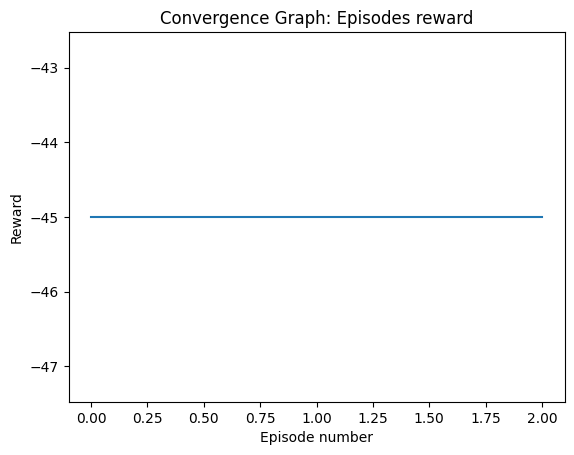

In [25]:
lineplot(data=episodes_rewards, title='Convergence Graph: Episodes reward', xlabel='Episode number', ylabel='Reward')

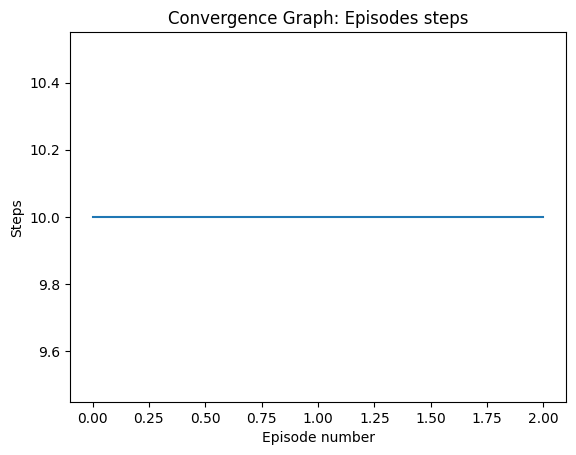

In [20]:
lineplot(data=episodes_steps, title='Convergence Graph: Episodes steps', xlabel='Episode number', ylabel='Steps')

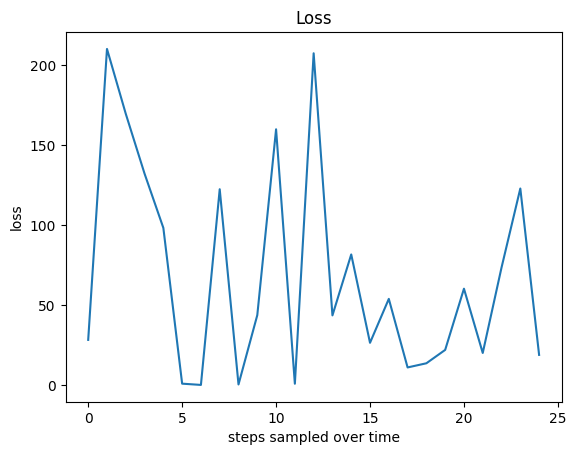

In [31]:
loss_values = [entry['loss'] for entry in train_loss]
lineplot(data=loss_values, title='Loss', xlabel='Step sampled over time', ylabel='Loss')

Streaming the policy after training is done:

In [ ]:
stream_policy(env, policy)

Streaming the policy in mid-training:

In [54]:
# random.seed(2) # keeping seed as in the assigment notebook
# env = EnvWrapper(num_boxes=1, compliance=1)
# policy, done_count, episodes_steps, episodes_rewards, train_loss = dqn(env=env, num_episodes=10, batch_size=32, gamma=0.9, ep_decay=0.9, epsilon=0.99,
#                                                                        target_freq_update=10, memory_buffer_size=10000, learning_rate=0.001, steps_cutoff=500 / 2, fixed_board=True,
#                                                                        layers_sizes=[16, 32], train_action_value_freq_update=1)

In [55]:
# stream_policy(env, policy)

## EX2 - PUSH & PULL - ONE BOX

In [56]:
#=============== DO NOT DELETE ===============
sok_2 = PushAndPullSokobanEnv(dim_room=(7, 7),num_boxes=1 ,max_steps=500)
# ============================================

NameError: name 'print_env_det' is not defined

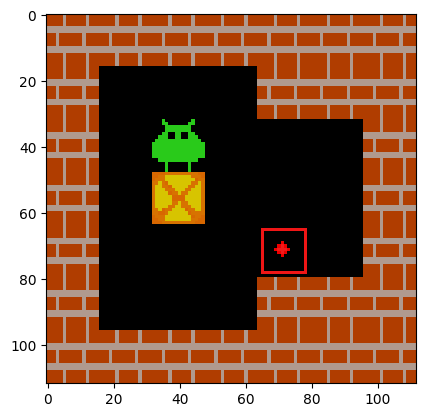

In [57]:
screen = sok_2.render(mode='rgb_array')
plt.imshow(sok_2.render('rgb_array'))
observation, reward, done, _ = sok_2.step(1)
print_env_det(sok_2)

### EX2 - Video test

In [ ]:
env = sok_2
start_time = time.time()
done = False
iter = 0
video_filename = 'imageio.mp4'
with imageio.get_writer(video_filename, fps=10) as video:
  while (iter < 10) or not done:
    time_passed = int(time.time() - start_time)
    if done or time_passed > 3:
      break
    iter +=1
    action = env.action_space.sample()
    observation, reward, done, info = env.step(action)
    video.append_data(env.render(mode='rgb_array'))
embed_mp4(video_filename)

## EX3 - PUSH & PULL - TWO BOXES

In [ ]:
#=============== DO NOT DELETE ===============
sok_3 = PushAndPullSokobanEnv(dim_room=(7, 7),num_boxes=2 ,max_steps=500)
# ============================================

Observation space: Box(0.0, 255.0, (112, 112, 3), float32)
Action space: Discrete(13)
Player position:[5 1]
Box mapping: {(1, 1): (4, 1), (3, 2): (4, 2)}


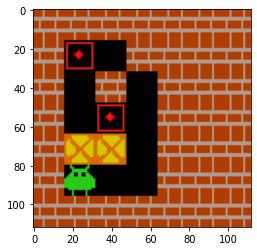

In [ ]:
screen = sok_3.render(mode='rgb_array')
plt.imshow(sok_3.render('rgb_array'))
print_env_det(sok_3)

### EX3 - Video test

In [ ]:
env = sok_3
start_time = time.time()
done = False
iter = 0
video_filename = 'imageio.mp4'
with imageio.get_writer(video_filename, fps=10) as video:
  while (iter < 10) or not done:
    time_passed = int(time.time() - start_time)
    if done or time_passed > 3:
      break
    iter +=1
    action = env.action_space.sample()
    observation, reward, done, info = env.step(action)
    video.append_data(env.render(mode='rgb_array'))
embed_mp4(video_filename)